<a href="https://colab.research.google.com/github/inoknCPE/AppliedML/blob/main/Gutierrez_COE232_Week_2_Build_a_Three_Layer_ANN_MLP_for_Fashion_MNIST_and_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2: Build a Three-Layer ANN/MLP for Fashion-MNIST and CIFAR-10
---

In [ ]:
import random, time, textwrap
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score

## Set a Reproducible Random Seed
---

In [ ]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Load Fashion-MNIST using torchvision.datasets.FashionMNIST
---

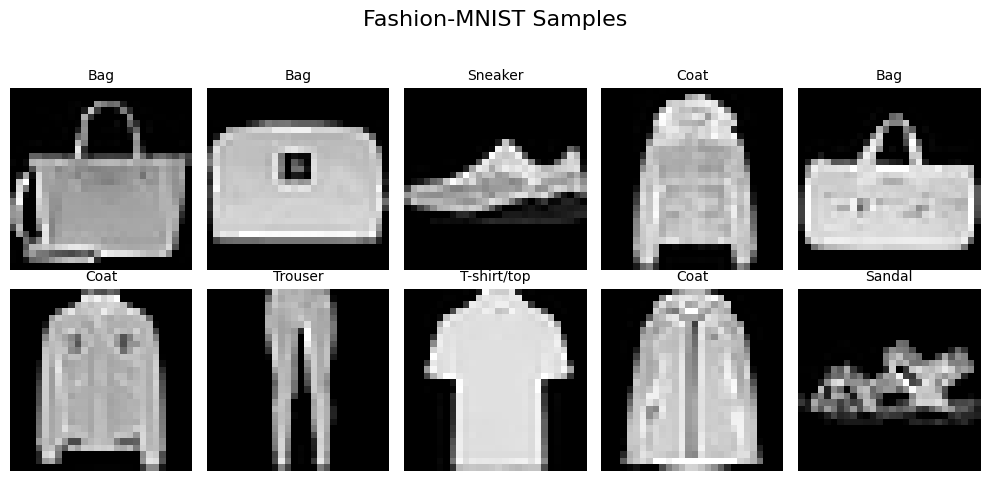

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(
    root='data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(
    root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)
class_names = train_data.classes

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
indices = np.random.choice(len(train_data), 10, replace=False)
for ax, idx in zip(axes.flat, indices):
    image, label = train_data[idx]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(class_names[label], fontsize=10)
    ax.axis("off")

plt.suptitle("Fashion-MNIST Samples", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Three Trainable Linear Layers
---


In [ ]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        logits = self.fc3(x)
        return logits

model = FashionMLP().to(device)

---
- Layer 1 uses 784 input features because each 28 × 28 image is flattened into a 784-element vector. The hidden layers use ReLU to introduce non-linearity, allowing the model to learn complex patterns that multiple linear layers alone cannot. Layer 3 has 10 output neurons because the Fashion-MNIST dataset contains 10 classes, with one output corresponding to each class. The model returns logits instead of probabilities because CrossEntropyLoss internally applies Softmax, making the training process more numerically stable.
---

## Model, Parameter Count, and Tensor Shapes
---

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
mem_bytes = total_params * 4
mem_mib = mem_bytes / (1024 * 1024)

print(model)
print(f"\nParameter Count : {total_params:,}")
print(f"Memory (float32): {mem_bytes:,} bytes = {mem_mib:.4f} MiB\n")
print("Tensor Shape")

def trace_forward(model, x):
    print(f"Input           : {tuple(x.shape)}")
    x = model.flatten(x)
    print(f"After Flatten   : {tuple(x.shape)}")
    x = model.fc1(x)
    print(f"After Layer 1   : {tuple(x.shape)}")
    x = model.activation(x)
    x = model.fc2(x)
    print(f"After Layer 2   : {tuple(x.shape)}")
    x = model.activation(x)
    logits = model.fc3(x)
    print(f"After Layer 3   : {tuple(logits.shape)}")
    return logits

sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)

model.eval()
with torch.no_grad():
    _ = trace_forward(model, sample_images)

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (activation): ReLU()
)

Parameter Count : 109,386
Memory (float32): 437,544 bytes = 0.4173 MiB

Tensor Shape
Input           : (64, 1, 28, 28)
After Flatten   : (64, 784)
After Layer 1   : (64, 128)
After Layer 2   : (64, 64)
After Layer 3   : (64, 10)


## Model Training and Evaluation
---

Epoch  1/10 | train_loss 0.5142 train_acc 0.8143 | test_loss 0.4891 train_acc 0.8271 | 20.7s
Epoch  2/10 | train_loss 0.3755 train_acc 0.8619 | test_loss 0.4180 train_acc 0.8451 | 19.5s
Epoch  3/10 | train_loss 0.3389 train_acc 0.8754 | test_loss 0.3823 train_acc 0.8598 | 20.2s
Epoch  4/10 | train_loss 0.3146 train_acc 0.8843 | test_loss 0.3581 train_acc 0.8696 | 18.9s
Epoch  5/10 | train_loss 0.2960 train_acc 0.8903 | test_loss 0.3797 train_acc 0.8604 | 20.4s
Epoch  6/10 | train_loss 0.2817 train_acc 0.8957 | test_loss 0.3482 train_acc 0.8754 | 19.0s
Epoch  7/10 | train_loss 0.2674 train_acc 0.8996 | test_loss 0.3373 train_acc 0.8786 | 20.0s
Epoch  8/10 | train_loss 0.2568 train_acc 0.9049 | test_loss 0.3384 train_acc 0.8789 | 19.0s
Epoch  9/10 | train_loss 0.2476 train_acc 0.9073 | test_loss 0.3635 train_acc 0.8746 | 20.1s
Epoch 10/10 | train_loss 0.2373 train_acc 0.9106 | test_loss 0.3583 train_acc 0.8793 | 19.1s


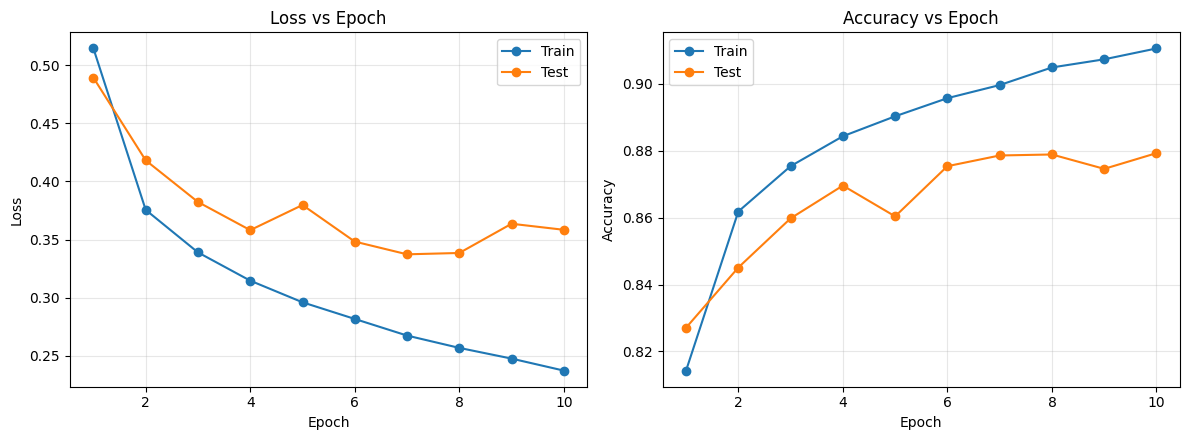

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # clear previous gradients
        logits = model(images)         # forward propagation
        loss = criterion(logits, labels)
        loss.backward()                # backpropagation
        optimizer.step()               # parameter update

        running_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return running_loss / total, correct / total, all_preds, all_labels

def run_training(model, train_loader, test_loader, epochs=10, lr=0.001, opt_name='adam', verbose=True):
    if opt_name == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif opt_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    else:
        raise ValueError(opt_name)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        test_loss, test_acc, _, _ = evaluate(model, test_loader)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        if verbose:
            print(f"Epoch {epoch+1:2d}/{epochs} | "
                  f"train_loss {train_loss:.4f} train_acc {train_acc:.4f} | "
                  f"test_loss {test_loss:.4f} train_acc {test_acc:.4f} | "
                  f"{time.time()-t0:.1f}s")
    return history

model = FashionMLP().to(device)
EPOCHS = 10
history = run_training(model, train_loader, test_loader, epochs=EPOCHS, lr=0.001, opt_name='adam')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], marker='o', label='Train')
axes[0].plot(epochs_range, history['test_loss'], marker='o', label='Test')
axes[0].set_title('Loss vs Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], marker='o', label='Train')
axes[1].plot(epochs_range, history['test_acc'], marker='o', label='Test')
axes[1].set_title('Accuracy vs Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Training and Test Accuracy per Epoch

### Confusion Matrix

Final test accuracy: 0.8793
Macro F1 score:      0.8770


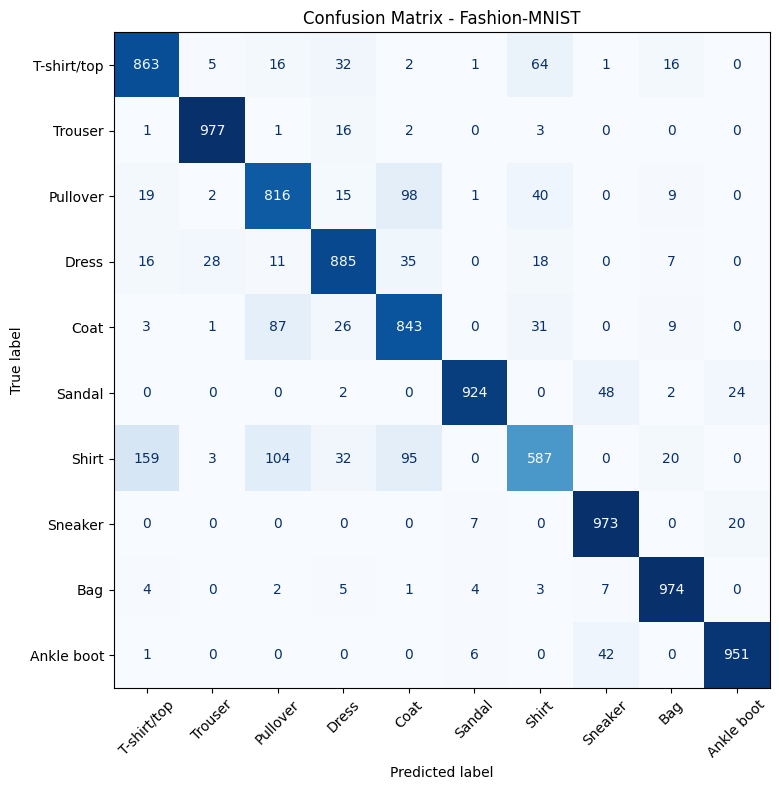


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.86      0.84      1000
     Trouser       0.96      0.98      0.97      1000
    Pullover       0.79      0.82      0.80      1000
       Dress       0.87      0.89      0.88      1000
        Coat       0.78      0.84      0.81      1000
      Sandal       0.98      0.92      0.95      1000
       Shirt       0.79      0.59      0.67      1000
     Sneaker       0.91      0.97      0.94      1000
         Bag       0.94      0.97      0.96      1000
  Ankle boot       0.96      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
_, final_test_acc, preds, labels = evaluate(model, test_loader)
macro_f1 = f1_score(labels, preds, average='macro')
print(f"Final test accuracy: {final_test_acc:.4f}")
print(f"Macro F1 score:      {macro_f1:.4f}")

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix - Fashion-MNIST')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(labels, preds, target_names=class_names))

### Sample Predictions

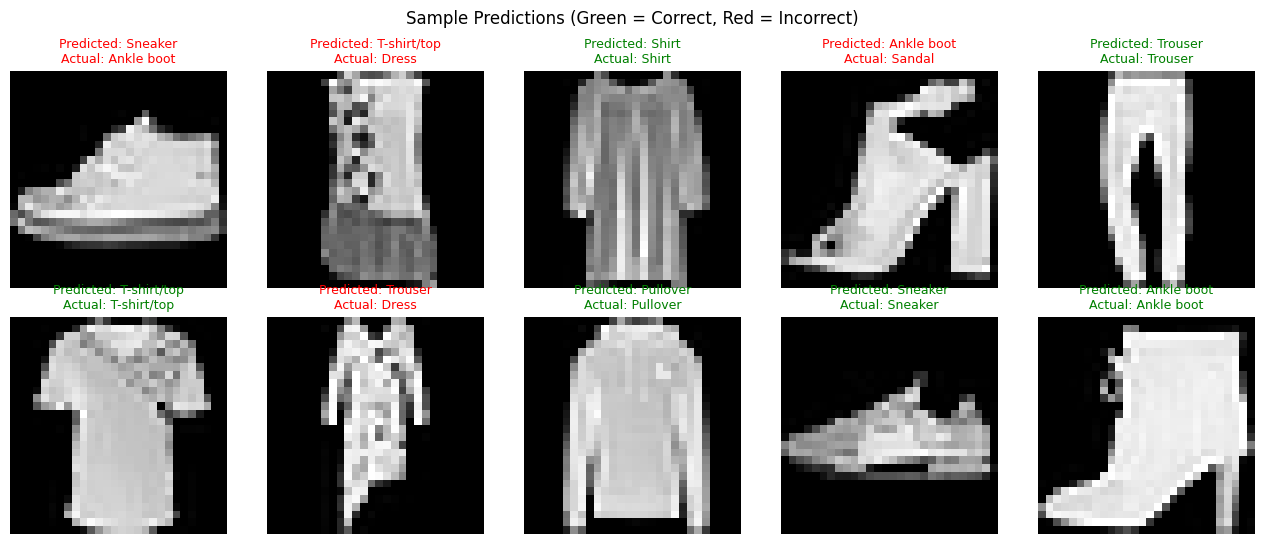

Sample Predictions Result: 6 correct + 4 incorrect predictions


In [ ]:
correct_idx = np.where(preds == labels)[0]
incorrect_idx = np.where(preds != labels)[0]

n_incorrect = min(4, len(incorrect_idx))
n_correct = 10 - n_incorrect
chosen_incorrect = np.random.choice(incorrect_idx, size=n_incorrect, replace=False)
chosen_correct = np.random.choice(correct_idx, size=n_correct, replace=False)
chosen = np.concatenate([chosen_correct, chosen_incorrect])
np.random.shuffle(chosen)

fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for ax, idx in zip(axes.flat, chosen):
    img, true_label = test_data[idx]
    pred_label = preds[idx]
    is_correct = (pred_label == true_label)
    ax.imshow(img.squeeze(), cmap='gray')
    color = 'green' if is_correct else 'red'
    ax.set_title(f"Predicted: {class_names[pred_label]}\nActual: {class_names[true_label]}",
                 fontsize=9, color=color)
    ax.axis('off')
plt.suptitle('Sample Predictions (Green = Correct, Red = Incorrect)')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()
print(f"Sample Predictions Result: {n_correct} correct + {n_incorrect} incorrect predictions")

## Controlled Hyperparameter Comparison
---


Controlled Hyperparameter Configurations
         Architecture Activation Optimizer  Learning rate  Batch size
Run                                                                  
A    784->128->64->10       ReLU       SGD          0.010          64
B    784->128->64->10       ReLU      ADAM          0.001          64
C    784->256->64->10       ReLU      ADAM          0.001          64
D    784->128->64->10       Tanh      ADAM          0.001          64

Controlled Hyperparameter Results
    Parameters Train loss Test loss Test accuracy Macro F1 Train time Inference time
Run                                                                                 
A      109,386     0.3744    0.4150        0.8469   0.8473      185.4           2.23
B      109,386     0.2354    0.3382        0.8838   0.8836      196.7           2.10
C      218,058     0.2264    0.3564        0.8806   0.8806      209.7           2.62
D      109,386     0.2570    0.3664        0.8731   0.8725      196.4         

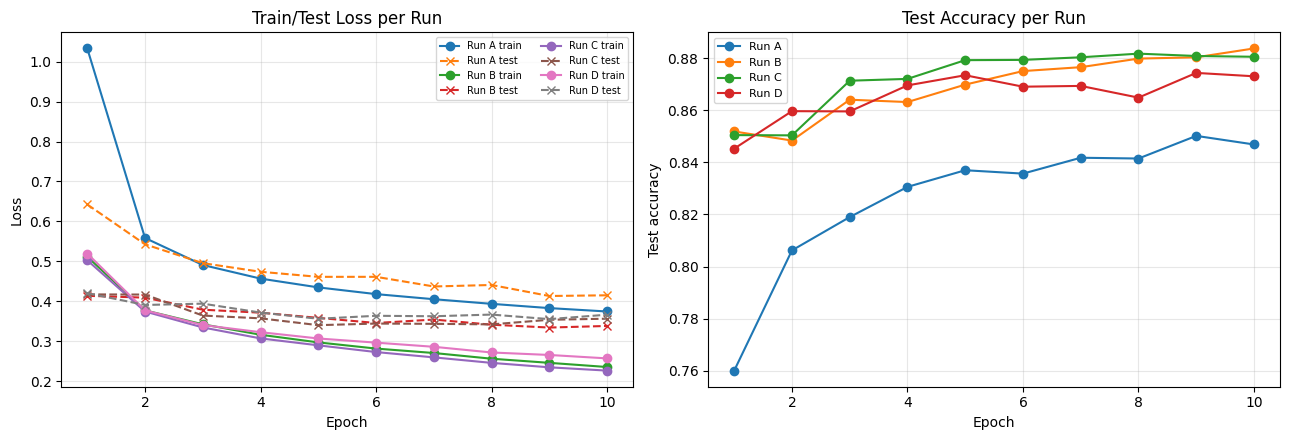

In [ ]:
class FashionMLPConfigurable(nn.Module):
    def __init__(self, hidden1=128, hidden2=64, activation_cls=nn.ReLU):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, 10)
        self.activation = activation_cls()

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        return self.fc3(x)


SWEEP_EPOCHS = 10

runs = {
    'A': dict(arch='784->128->64->10', hidden1=128, hidden2=64, activation=nn.ReLU,
              optimizer='sgd',  lr=0.01,   batch_size=64),
    'B': dict(arch='784->128->64->10', hidden1=128, hidden2=64, activation=nn.ReLU,
              optimizer='adam', lr=0.001,  batch_size=64),
    'C': dict(arch='784->256->64->10', hidden1=256, hidden2=64, activation=nn.ReLU,
              optimizer='adam', lr=0.001,  batch_size=64),
    'D': dict(arch='784->128->64->10', hidden1=128, hidden2=64, activation=nn.Tanh,
              optimizer='adam', lr=0.001,  batch_size=64),
}

run_histories = {}
run_results = {}

for run_id, cfg in runs.items():
    tr_loader = DataLoader(train_data, batch_size=cfg['batch_size'], shuffle=True)
    te_loader = DataLoader(test_data, batch_size=256, shuffle=False)

    m = FashionMLPConfigurable(cfg['hidden1'], cfg['hidden2'], cfg['activation']).to(device)
    if cfg['optimizer'] == 'sgd':
        opt = torch.optim.SGD(m.parameters(), lr=cfg['lr'])
    else:
        opt = torch.optim.Adam(m.parameters(), lr=cfg['lr'])

    hist = {'train_loss': [], 'test_loss': [], 'test_acc': []}
    t0 = time.time()
    for ep in range(SWEEP_EPOCHS):
        tr_loss, tr_acc = train_one_epoch(m, tr_loader, opt)
        te_loss, te_acc, _, _ = evaluate(m, te_loader)
        hist['train_loss'].append(tr_loss)
        hist['test_loss'].append(te_loss)
        hist['test_acc'].append(te_acc)
    train_time = time.time() - t0

    t0 = time.time()
    _, final_test_acc, preds_r, labels_r = evaluate(m, te_loader)
    inference_time = time.time() - t0

    n_params = sum(p.numel() for p in m.parameters())

    macro_f1_r = f1_score(labels_r, preds_r, average='macro')

    run_histories[run_id] = hist
    run_results[run_id] = {
        'Run': run_id,
        'Architecture': cfg['arch'],
        'Activation': cfg['activation'].__name__,
        'Optimizer': cfg['optimizer'].upper(),
        'LR': cfg['lr'],
        'Batch size': cfg['batch_size'],
        'Parameters': n_params,
        'Train loss': hist['train_loss'][-1],
        'Test loss': hist['test_loss'][-1],
        'Test accuracy': final_test_acc,
        'Macro F1': macro_f1_r,
        'Train time (s)': train_time,
        'Inference time (s)': inference_time,
    }

results_df = pd.DataFrame(run_results.values()).set_index('Run')

config_cols = ['Architecture', 'Activation', 'Optimizer', 'LR', 'Batch size']
config_table = results_df[config_cols].rename(columns={'LR': 'Learning rate'})

metrics_table = results_df[['Parameters', 'Train loss', 'Test loss', 'Test accuracy',
                             'Macro F1', 'Train time (s)', 'Inference time (s)']].copy()
metrics_table['Parameters'] = metrics_table['Parameters'].map('{:,}'.format)
metrics_table['Train loss'] = metrics_table['Train loss'].map('{:.4f}'.format)
metrics_table['Test loss'] = metrics_table['Test loss'].map('{:.4f}'.format)
metrics_table['Test accuracy'] = metrics_table['Test accuracy'].map('{:.4f}'.format)
metrics_table['Macro F1'] = metrics_table['Macro F1'].map('{:.4f}'.format)
metrics_table['Train time (s)'] = metrics_table['Train time (s)'].map('{:.1f}'.format)
metrics_table['Inference time (s)'] = metrics_table['Inference time (s)'].map('{:.2f}'.format)
metrics_table = metrics_table.rename(columns={
    'Train time (s)': 'Train time',
    'Inference time (s)': 'Inference time',
})

print("\nControlled Hyperparameter Configurations")
print(config_table.to_string())

print("\nControlled Hyperparameter Results")
print(metrics_table.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for run_id, hist in run_histories.items():
    axes[0].plot(range(1, SWEEP_EPOCHS + 1), hist['train_loss'], marker='o', label=f"Run {run_id} train")
    axes[0].plot(range(1, SWEEP_EPOCHS + 1), hist['test_loss'], marker='x', linestyle='--', label=f"Run {run_id} test")
axes[0].set_title('Train/Test Loss per Run'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(alpha=0.3)

for run_id, hist in run_histories.items():
    axes[1].plot(range(1, SWEEP_EPOCHS + 1), hist['test_acc'], marker='o', label=f"Run {run_id}")
axes[1].set_title('Test Accuracy per Run'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test accuracy')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Recommendation
---
The recommended configuration for a CPU-only computer is Run B, which uses the architecture 784→128→64→10 with ReLU activation, the Adam optimizer, a learning rate of 0.001, and a batch size of 64. This configuration provides the best balance between performance, computational cost, and model complexity under limited hardware resources. As shown in the results, Run B achieved the highest test accuracy (88.38%), the highest Macro F1 score (0.8836), and the lowest test loss (0.3382), demonstrating the strongest generalization among all configurations. Although Run C doubled the parameter count from 109,386 to 218,058 by increasing the first hidden layer, it did not improve accuracy and required the longest training time (215.2 s), making the additional memory and computation unnecessary. Run A trained slightly faster but achieved lower accuracy due to the slower convergence of SGD, while Run D also performed slightly worse than Run B in both test accuracy and Macro F1 score. Considering the constraints of limited CPU processing power, memory, and training time, Run B offers the most efficient and reliable configuration without increasing model size, making it the preferred choice for resource-constrained systems.